In [2]:
# !pip install --quiet sentence-transformers
# !pip install --quiet xgboost
# !pip install imbalanced-learn
# !pip install -q sentence-transformers xgboost joblib
# !pip install -U xgboost scikit-learn
# !pip install --upgrade imbalanced-learn
# !pip install numpy sentence-transformers xgboost joblib imbalanced-learn scikit-learn



In [3]:
%%time

import os, time, json
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelBinarizer

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier

from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

# from imblearn.over_sampling import KMeansSMOTE
from imblearn.over_sampling import BorderlineSMOTE
from joblib import dump
import torch



CPU times: total: 0 ns
Wall time: 108 μs


# Data Preprocessing
In the below cells, we will integrate dataset, handle missing values, encode categorical variables, balance the data and scale features to prepare the data for machine learning models.

In [4]:
df: pd.DataFrame = pd.read_csv(r'./dataset/Combined Data.csv')
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


#### About dataset
<class 'pandas.core.frame.DataFrame'>
## Data shape : 
RangeIndex: 53043 entries, 0 to 53042
## Data columns (total 3 columns):
| s.no | Column      | Non-Null Count   | Dtype  |
|------|-------------|------------------:|--------|
| 0    | Unnamed: 0  | 53043 non-null    | int64  |
| 1    | statement   | 52681 non-null    | object |
| 2    | status      | 53043 non-null    | object |
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
Data loaded successfully.
Shape: (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status'],
## Missing values:
| Column       | Missing Count |
|--------------|---------------:|
| Unnamed: 0   | 0              |
| statement    | 362            |
| status       | 0              |

dtype: int64

Info:
None

## Description:
         Unnamed: 0
| Statistic | Value         |
|-----------|--------------:|
| count     | 53043.000000  |
| mean      | 26521.000000  |
| std       | 15312.339501  |
| min       | 0.000000      |
| 25%       | 13260.500000  |
| 50%       | 26521.000000  |
| 75%       | 39781.500000  |
| max       | 53042.000000  |
## Value Counts for classes in output colmn
| status                 | Count  |
|------------------------|-------:|
| Normal                 | 16351  |
| Depression             | 15404  |
| Suicidal               | 10653  |
| Anxiety                | 3888   |
| Bipolar                | 2877   |
| Stress                 | 2669   |
| Personality disorder   | 1201   |
Name: count, dtype: int64

In [5]:
# print(f"Data loaded successfully.\nShape: {df.shape}\nColumns: {df.columns.tolist()},\nMissing values:\n{df.isnull().sum()},\nInfo:\n{df.info()},\nDescription:\n{df.describe()}")

In [6]:
# df.isnull().sum()

In [7]:
# df['status'].value_counts()

In [8]:
# df.shape

### Step 1: handeling missing values
since we have 362 missing rows whis is 0.7% so statistically speaking they are negligible so i am deleting them the code i am using in given
```df = df.dropna(subset=['statement']).reset_index(drop=True)```

In [9]:
df = df.dropna(subset=['statement']).reset_index(drop=True)
df.shape, df.isnull().sum()

((52681, 3),
 Unnamed: 0    0
 statement     0
 status        0
 dtype: int64)

### Step 2: handleing imbalanced data
So as you know the dataset is imbalanced so here we are going to use sampeling method, as balancing 52k (new) records is harder and impractical so first we will be using <b>Stratified Sampling</b> what it does is, whenever we folds the dataset it ensures that the original ratio(the class percentage in the dataset) remains same in simple words, our <b><u>Stress</u></b> class has 5.0% ratio so in every fold it is maintend same. before that we will be shufflling the data

In [10]:
df: pd.DataFrame = df.sample(frac=1, random_state=42).reset_index(drop=True)
skf: StratifiedKFold = StratifiedKFold(n_splits=5,shuffle=True,random_state=43)

### Step 3: SMOTE (Synthetic Minority Oversampling Technique)

In our previous step, we handled imbalance using simple random oversampling — which duplicated samples of rare classes.  
While that helped equalize the data counts, it didn’t actually **add any new information** — the model still saw the same examples multiple times.  

To overcome this, we’ll use **SMOTE (Synthetic Minority Oversampling Technique)**.  
Instead of duplicating samples, SMOTE **creates new, synthetic data points** for minority classes by interpolating between existing ones.

Here’s how it works:
- SMOTE picks a random sample from the minority class.
- It finds its nearest neighbors (usually 5).
- Then it creates **synthetic points** along the line between the sample and its neighbors — forming new, realistic data.  
  (Imagine filling in the “gaps” between sparse data points.)

We’ll apply SMOTE **only to the training data**, not the test data, so:
- The model learns from balanced data.
- Validation/test sets still reflect the true, real-world class distribution.

This helps the model generalize better — especially for rare labels like *Personality disorder* and *Stress* —  
without overfitting on duplicated examples.


In [11]:
from sklearn.preprocessing import LabelEncoder

smote = BorderlineSMOTE(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def is_long_text(series, max_unique_ratio=0.5, max_length_threshold=100):
    if series.dtype != 'object':
        return False
    avg_len = series.astype(str).map(len).mean()
    unique_ratio = series.nunique() / len(series)
    return avg_len > max_length_threshold or unique_ratio > max_unique_ratio

for fold, (train_idx, test_idx) in enumerate(skf.split(df, df['status'])):
    print(f"\n=== Fold {fold + 1} ===")

    df_train, df_test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

    X_train = df_train.drop(columns=['status'])
    y_train = df_train['status']
    X_test = df_test.drop(columns=['status'])
    y_test = df_test['status']

    text_cols = [col for col in X_train.columns if is_long_text(X_train[col])]
    if text_cols:
        print(f"Dropping text-heavy columns before SMOTE: {text_cols}")
        X_train = X_train.drop(columns=text_cols)
        X_test = X_test.drop(columns=text_cols, errors='ignore')

    for col in X_train.columns:
        if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category':
            le = LabelEncoder()
            all_values = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
            le.fit(all_values)  
            X_train[col] = le.transform(X_train[col].astype(str))
            X_test[col] = le.transform(X_test[col].astype(str))

    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])

    print("Applying SMOTE balancing...")
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("✅ SMOTE applied successfully — classes balanced")

    print("Fold Summary:")
    print("X_train shape:", X_train_res.shape)
    print("y_train shape:", y_train_res.shape)
    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)
    print("-" * 60)



=== Fold 1 ===
Dropping text-heavy columns before SMOTE: ['statement']
Applying SMOTE balancing...
✅ SMOTE applied successfully — classes balanced
Fold Summary:
X_train shape: (91518, 1)
y_train shape: (91518,)
X_test shape: (10537, 1)
y_test shape: (10537,)
------------------------------------------------------------

=== Fold 2 ===
Dropping text-heavy columns before SMOTE: ['statement']
Applying SMOTE balancing...
✅ SMOTE applied successfully — classes balanced
Fold Summary:
X_train shape: (91518, 1)
y_train shape: (91518,)
X_test shape: (10536, 1)
y_test shape: (10536,)
------------------------------------------------------------

=== Fold 3 ===
Dropping text-heavy columns before SMOTE: ['statement']
Applying SMOTE balancing...
✅ SMOTE applied successfully — classes balanced
Fold Summary:
X_train shape: (91518, 1)
y_train shape: (91518,)
X_test shape: (10536, 1)
y_test shape: (10536,)
------------------------------------------------------------

=== Fold 4 ===
Dropping text-heavy c

#### We finally completed data preprocessing, now comes ml model building

# Ml Model building 

Here we are going with ensemble method learning, we are applying following algos <ol>
<li><a href="https://scikit-learn.org/stable/modules/naive_bayes.html">Naive Bayes</a>: A probabilistic classifier based on Bayes’ theorem that assumes features are conditionally independent.</li>
<li><a href="https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html">RandomForestClassifier</a>: An ensemble learning method that builds multiple decision trees and combines their outputs for robust classification.</li>
<li><a href="https://www.geeksforgeeks.org/machine-learning/xgbclassifier/">XGBClassifier</a>: An optimized gradient boosting algorithm that builds sequential decision trees with regularization for high accuracy and efficiency.</li>
</ol>

Before we train the model we are going to apply feature extraction of text, using <a href="https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/">TF-IDF</a>(Term Frequency-Inverse Document Frequency) it defination is <i>is a statistical method used in natural language processing and information retrieval to evaluate how important a word is to a document in relation to a larger collection of documents. TF-IDF combines two components<i>

So we are going to apply that then ml training, in <a href="https://www.geeksforgeeks.org/machine-learning/a-comprehensive-guide-to-ensemble-learning/">Ensemble learning</a> they are multiple methods like <a href="https://www.ibm.com/think/topics/bagging">Bagging, <a href="https://www.ibm.com/think/topics/boosting">Boosting</a>, <a href="https://www.geeksforgeeks.org/machine-learning/voting-in-machine-learning/">Voting</a> we are going to use voting here 

## Voting 
### Voting Strategies:
1. <b><u>Hard Voting</u></b> : The class that receives the majority of votes is selected as the final prediction. It is commonly used in classification problems. In regression, it predicts the average of the individual predictions.
2. <b><u>Soft Voting</u></b> : Weighted average of predicted probabilities is used to make the final prediction. It is suitable when classifiers provide probability estimates. In other words, for each class, it sums the predicted probabilities and predicts the class with the highest sum.

Here we will be using Soft voting

In [12]:
CSV_PATH = r'./dataset/Combined Data.csv'   
TEXT_COL = "statement"
LABEL_COL = "status"
SAVE_DIR = "model_artifacts_stacking"

os.makedirs(SAVE_DIR, exist_ok=True)

N_SPLITS = 5
USE_SMOTE = True
RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


Using: cpu


In [13]:
%%time

df = pd.read_csv(CSV_PATH)
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

texts = df[TEXT_COL].astype(str).tolist()
labels = df[LABEL_COL].astype(str).tolist()
classes = sorted(df[LABEL_COL].unique())
df = df.dropna(subset=['statement']).reset_index(drop=True)
df.shape, df.isnull().sum()
print("Dataset:", df.shape)
print("Classes:", classes)


Dataset: (52681, 2)
Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
CPU times: total: 672 ms
Wall time: 670 ms


In [ ]:
%%time

device = "cuda" if torch.cuda.is_available() else "cpu"
EMBED_MODEL = "paraphrase-mpnet-base-v2" if device=='cuda' else "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL, device=device)

print("Encoding sentences (GPU)…")
t0 = time.time()

X_emb = embedder.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    device=device
)

print("Embedding done:", X_emb.shape, "Time:", time.time() - t0)

X = np.array(X_emb)
y = np.array(labels)


Encoding sentences (GPU)…


Batches:  25%|██▌       | 210/824 [08:00<20:02,  1.96s/it]

In [ ]:
%%time

# Fast but strong SVC substitute (much faster than SVC(probability=True))
fast_svc = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    method="sigmoid",
    cv=3
)

# XGBoost - GPU Enabled
xgb_params = {
    "n_estimators": 200,          # increased trees (GPU removed)
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "eval_metric": "mlogloss",
    "tree_method": "hist",        # FASTEST on CPU
    "n_jobs": -1,
}


# if device == "cuda":
#     xgb_params.update({
#         "tree_method": "gpu_hist",
#         "predictor": "gpu_predictor"
#     })

base_estimators = [
    ("nb", GaussianNB()),
    ("xgb", XGBClassifier(**xgb_params)),
    ("svc", fast_svc),
    ("lr", LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="saga"))
]

meta_estimator = LogisticRegression(max_iter=2000, solver="saga")

stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1,
    verbose=1
)


print("Models initialized.")


Models initialized.
CPU times: total: 15.6 ms
Wall time: 18.7 ms


In [ ]:
%%time

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

best_auc = -1
best_fold_train = None
best_fold_test = None
best_model_path = None
fold_reports_all = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print("\n==============================")
    print(f"==========  FOLD {fold}  ==========")
    print("==============================")

    fold_start = time.time()

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    smote_time = None
    if USE_SMOTE:
        print("Applying BorderlineSMOTE… (stable for imbalanced data)")
        sm0 = time.time()

        sm = BorderlineSMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=3,
        kind="borderline-1"
    )

        X_train, y_train = sm.fit_resample(X_train, y_train)
        smote_time = time.time() - sm0

        print("BorderlineSMOTE complete:", X_train.shape, "Time:", smote_time)

    print("Training stacking model…")
    t0 = time.time()
    stack_model.fit(X_train, y_train)
    train_time = time.time() - t0
    print("Train time:", train_time)

    t0 = time.time()
    y_pred = stack_model.predict(X_test)
    y_proba = stack_model.predict_proba(X_test)
    test_time = time.time() - t0

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    macro_precision = precision_score(y_test, y_pred, average="macro")
    macro_recall = recall_score(y_test, y_pred, average="macro")

    lb = LabelBinarizer()
    lb.fit(classes)
    y_test_bin = lb.transform(y_test)

    auc_macro = roc_auc_score(
        y_test_bin, y_proba,
        average="macro",
        multi_class="ovr"
    )

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred))
    print("AUC:", auc_macro)

    # Save per-fold report
    test_df = pd.DataFrame({
        TEXT_COL: df.iloc[test_idx][TEXT_COL].values,
        "true": y_test,
        "pred": y_pred
    })
    for i, cls_name in enumerate(classes):
        test_df[f"proba_{cls_name}"] = y_proba[:, i]

    fold_path = f"{SAVE_DIR}/fold_{fold}_test.csv"
    test_df.to_csv(fold_path, index=False)

    Save best
    if auc_macro > best_auc:
        print("🔥 New Best Model on Fold", fold)

        best_auc = auc_macro
        best_model_path = f"{SAVE_DIR}/best_model_auc_{auc_macro:.4f}.joblib"

        dump(stack_model, best_model_path)
        embedder.save(f"{SAVE_DIR}/embedder/")

        best_fold_train = df.iloc[train_idx][[TEXT_COL, LABEL_COL]]
        best_fold_test = test_df.copy()

    fold_t = time.time() - fold_start
    print("Fold time:", fold_t)

    fold_reports_all.append({
        "fold": fold,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_auc": auc_macro,
        "time_fold_s": fold_t
    })


SyntaxError: invalid syntax (<unknown>, line 79)

In [ ]:
X.shape

(52681, 384)

In [ ]:
%%time

best_fold_train.to_csv(f"{SAVE_DIR}/training.csv", index=False)
best_fold_test.to_csv(f"{SAVE_DIR}/testing.csv", index=False)

json.dump({
    "best_auc": best_auc,
    "folds": fold_reports_all
}, open(f"{SAVE_DIR}/summary.json", "w"), indent=4)
from sklearn.pipeline import Pipeline

final_pipeline = {
    "embedder": embedder,
    "model": stack_model,
    "classes": classes
}

dump(final_pipeline, "./model_artifacts_stacking/final_pipeline.joblib")


print("Saved best results.")


Saved best results.
CPU times: total: 2.16 s
Wall time: 1.18 s


In [ ]:
from joblib import load

pipeline = load("./model_artifacts_stacking/final_pipeline.joblib")  
embedder = pipeline["embedder"]
model = pipeline["model"]
classes = pipeline["classes"]


In [ ]:
texts = [
    # Anxiety
    "My chest feels tight and I keep thinking something bad will happen soon.",
    
    # Bipolar
    "Yesterday I felt unstoppable, but today I can’t even get out of bed.",
    
    # Depression
    "I don’t find joy in anything anymore. Even the things I used to love feel empty.",
    
    # Normal
    "Had a long day but I’m feeling okay now, just tired and ready to sleep.",
    
    # Personality Disorder
    "Sometimes I don’t even recognize myself. I act like a stranger and it scares me.",
    
    # Stress
    "Deadlines are piling up, and I can feel the pressure crushing me.",
    
    # Suicidal
    "I just wish I could stop existing for a while. Everything hurts too much.",
    
    # Normal (again)
    "Spent the day with my family, felt peaceful and grounded for once.",
    
    # Anxiety (social)
    "Every time someone looks at me, I start overthinking what they think of me.",
    
    # Bipolar (mild mania)
    "I cleaned my entire house, made five plans, and I can’t stop talking — it’s like I’m on fire.",
]


In [ ]:
print("Encoding text...")
X_emb = embedder.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)


Encoding text...


Batches: 100%|██████████| 1/1 [00:00<00:00, 12.76it/s]


In [ ]:
preds = model.predict(X_emb)


In [ ]:
print("\nMODEL PREDICTIONS ON UNSEEN TEXT:\n")
for i, (t, p) in enumerate(zip(texts, preds), 1):
    print(f"{i:02d}. {p:<22} | {t}")



MODEL PREDICTIONS ON UNSEEN TEXT:

01. Anxiety                | My chest feels tight and I keep thinking something bad will happen soon.
02. Depression             | Yesterday I felt unstoppable, but today I can’t even get out of bed.
03. Depression             | I don’t find joy in anything anymore. Even the things I used to love feel empty.
04. Anxiety                | Had a long day but I’m feeling okay now, just tired and ready to sleep.
05. Personality disorder   | Sometimes I don’t even recognize myself. I act like a stranger and it scares me.
06. Normal                 | Deadlines are piling up, and I can feel the pressure crushing me.
07. Suicidal               | I just wish I could stop existing for a while. Everything hurts too much.
08. Normal                 | Spent the day with my family, felt peaceful and grounded for once.
09. Suicidal               | Every time someone looks at me, I start overthinking what they think of me.
10. Normal                 | I cleaned my en

In [ ]:
def predict_texts(text_list):
    X_e = embedder.encode(text_list, batch_size=64, convert_to_numpy=True)
    preds = model.predict(X_e)
    probs = model.predict_proba(X_e)
    return preds, probs

labels, probabilities = predict_texts(texts)
for i, (t, label, prob) in enumerate(zip(texts, labels, probabilities), 1):
    print(f"{i:02d}. Text: {t}")
    print(f"     Predicted Label: {label}")
    top_idx = np.argsort(prob)[::-1][:3]
    for j in top_idx:
        print(f"     {classes[j]:<22}: {prob[j]:.4f}")
    print()


01. Text: My chest feels tight and I keep thinking something bad will happen soon.
     Predicted Label: Anxiety
     Anxiety               : 0.9016
     Depression            : 0.0679
     Suicidal              : 0.0121

02. Text: Yesterday I felt unstoppable, but today I can’t even get out of bed.
     Predicted Label: Depression
     Depression            : 0.5131
     Personality disorder  : 0.3555
     Suicidal              : 0.0752

03. Text: I don’t find joy in anything anymore. Even the things I used to love feel empty.
     Predicted Label: Depression
     Depression            : 0.8647
     Personality disorder  : 0.1061
     Suicidal              : 0.0179

04. Text: Had a long day but I’m feeling okay now, just tired and ready to sleep.
     Predicted Label: Anxiety
     Anxiety               : 0.4166
     Depression            : 0.3481
     Suicidal              : 0.0746

05. Text: Sometimes I don’t even recognize myself. I act like a stranger and it scares me.
     Predict

# Visualization

In [ ]:
# !pip install umap-learn
# !pip install wordcloud matplotlib

In [ ]:
%%time
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

import umap


CPU times: total: 0 ns
Wall time: 35.8 μs


## CLASS DISTRIBUTION (BAR + PIE)

<timed exec>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



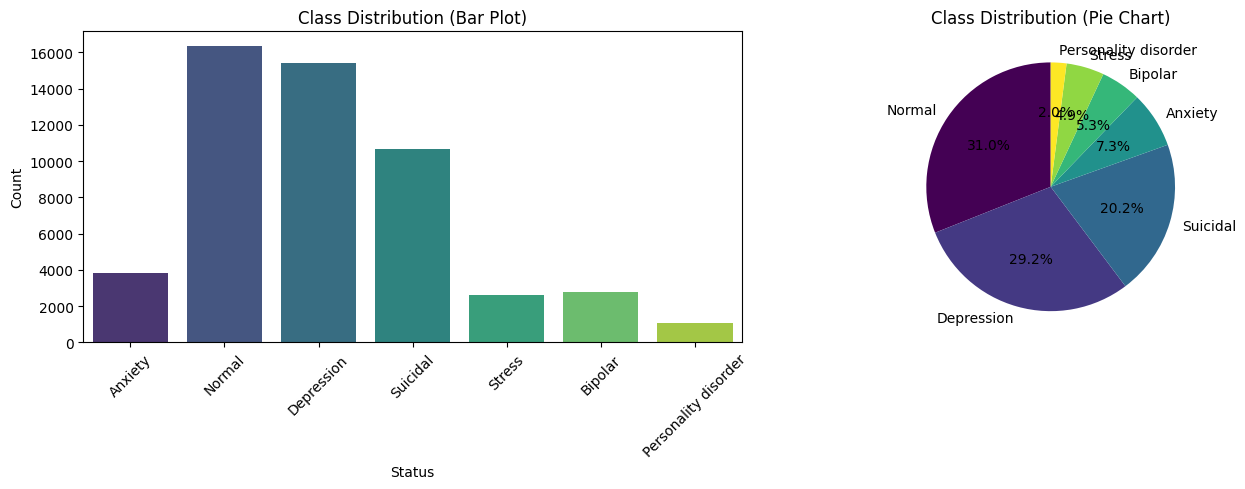

CPU times: total: 703 ms
Wall time: 767 ms


In [ ]:
%%time

plt.figure(figsize=(14,5))

# --- Bar chart ---
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="status", palette="viridis")
plt.title("Class Distribution (Bar Plot)")
plt.xticks(rotation=45)
plt.xlabel("Status")
plt.ylabel("Count")

# --- Pie chart ---
plt.subplot(1, 2, 2)
df['status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    cmap="viridis"
)
plt.title("Class Distribution (Pie Chart)")
plt.ylabel("")

plt.tight_layout()
plt.show()


## WORDCLOUD FOR DIFFERENT CLASSES

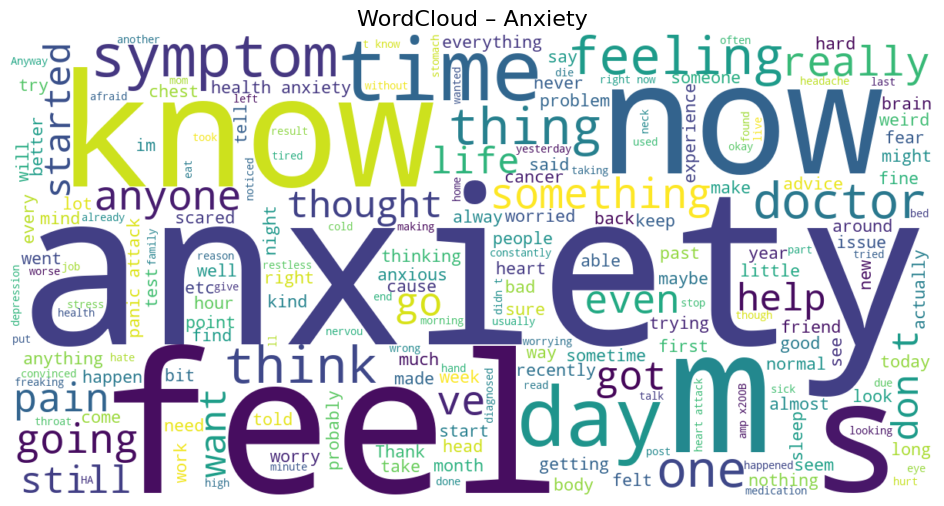

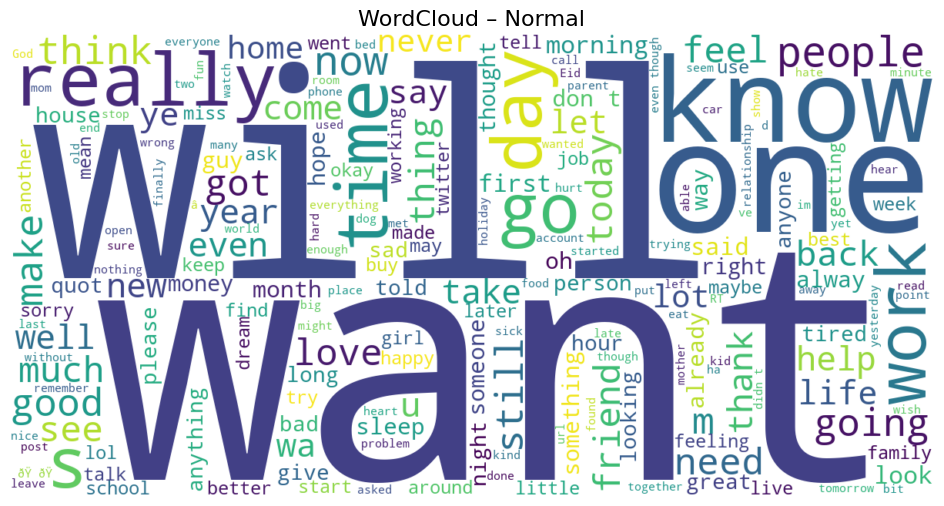

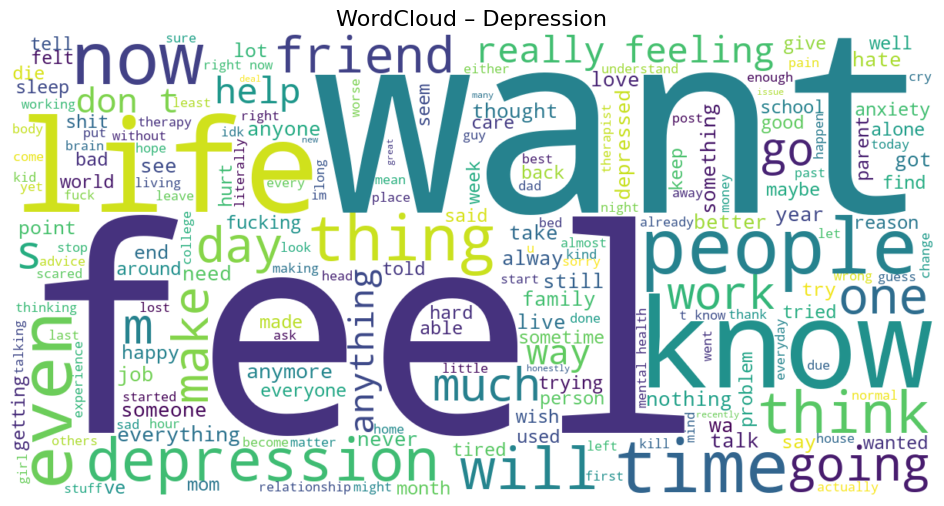

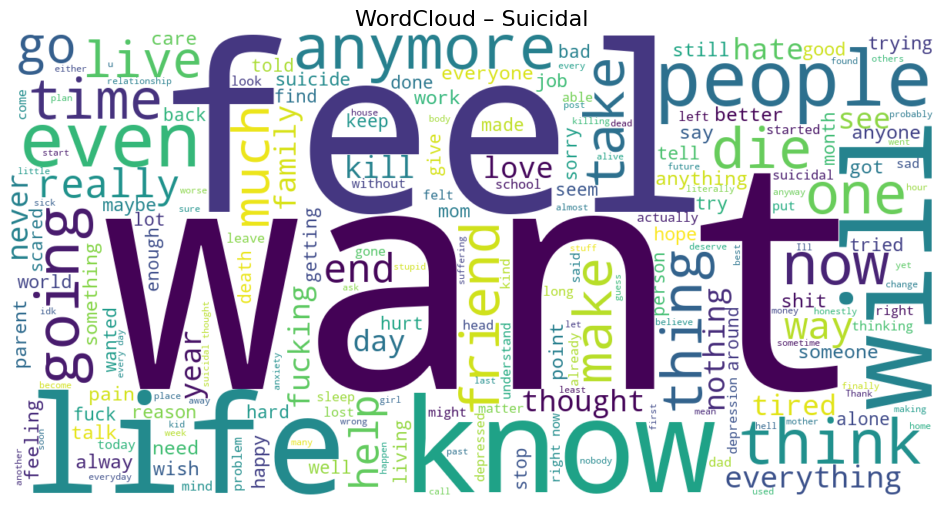

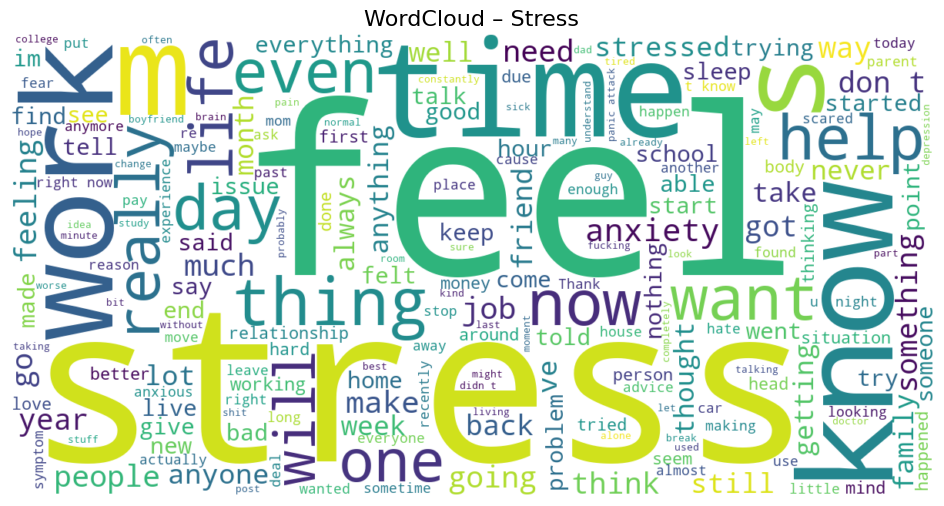

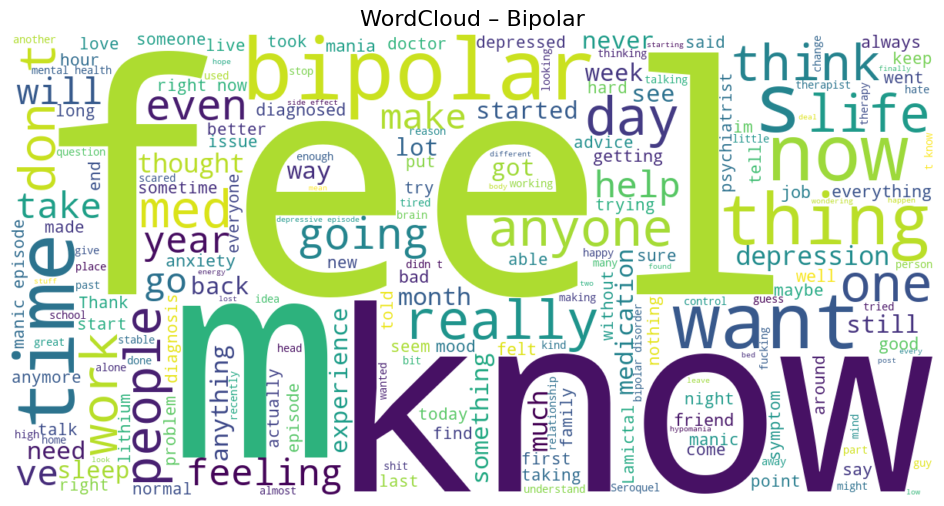

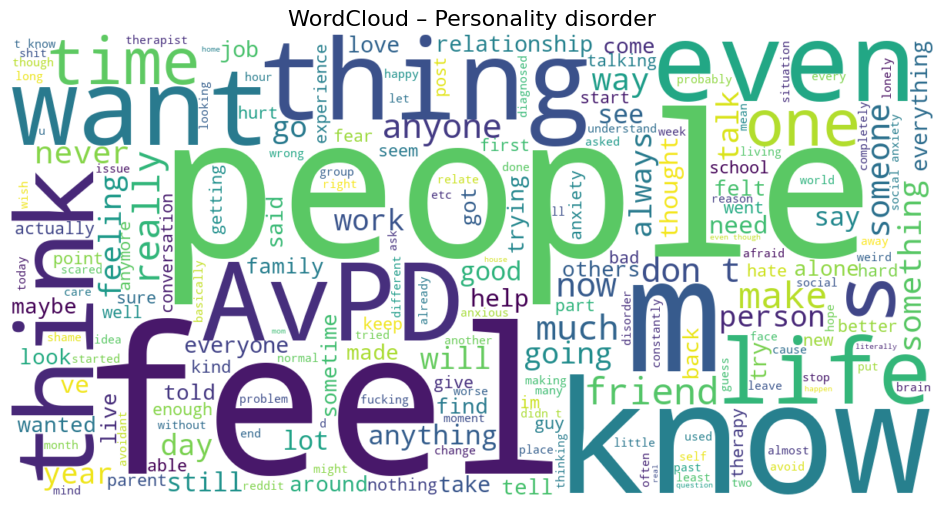

CPU times: total: 34.8 s
Wall time: 35.2 s


In [ ]:
%%time

classes = df["status"].unique()

for c in classes:
    text = " ".join(df[df["status"] == c]["statement"].astype(str).tolist())
    wc = WordCloud(width=1200, height=600, background_color="white").generate(text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud – {c}", fontsize=16)
    plt.axis("off")
    plt.show()


## TOP WORD FREQUENCIES (TF-IDF)

<timed exec>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



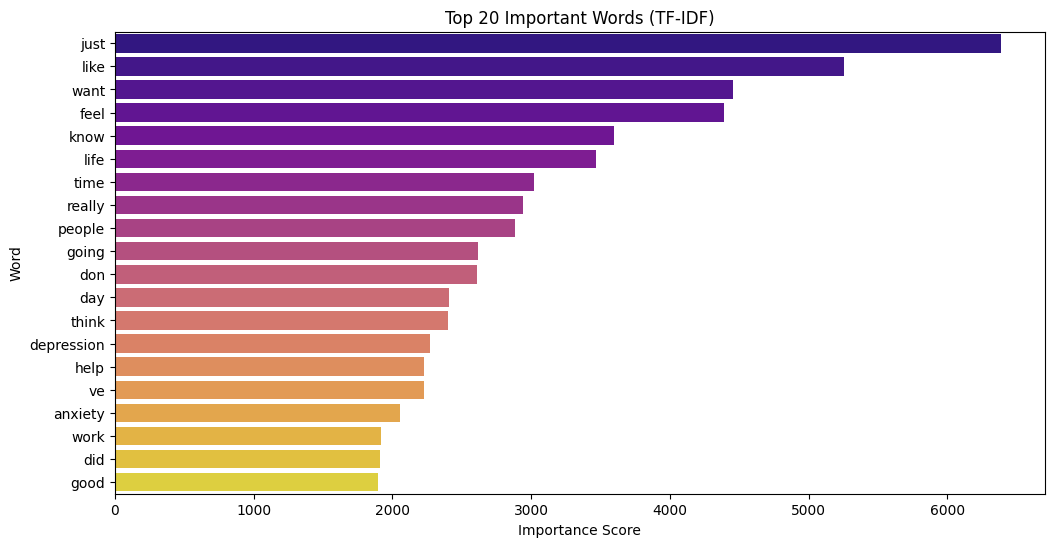

CPU times: total: 6.89 s
Wall time: 6.94 s


In [ ]:
%%time
tfidf = TfidfVectorizer(max_features=50, stop_words="english")
X_tfidf = tfidf.fit_transform(df["statement"])
words = tfidf.get_feature_names_out()

word_scores = X_tfidf.sum(axis=0).A1
freq_df = pd.DataFrame({"word": words, "score": word_scores})
freq_df = freq_df.sort_values("score", ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=freq_df, x="score", y="word", palette="plasma")
plt.title("Top 20 Important Words (TF-IDF)")
plt.xlabel("Importance Score")
plt.ylabel("Word")
plt.show()


## TF-IDF PCA 2D CLUSTER PLOT

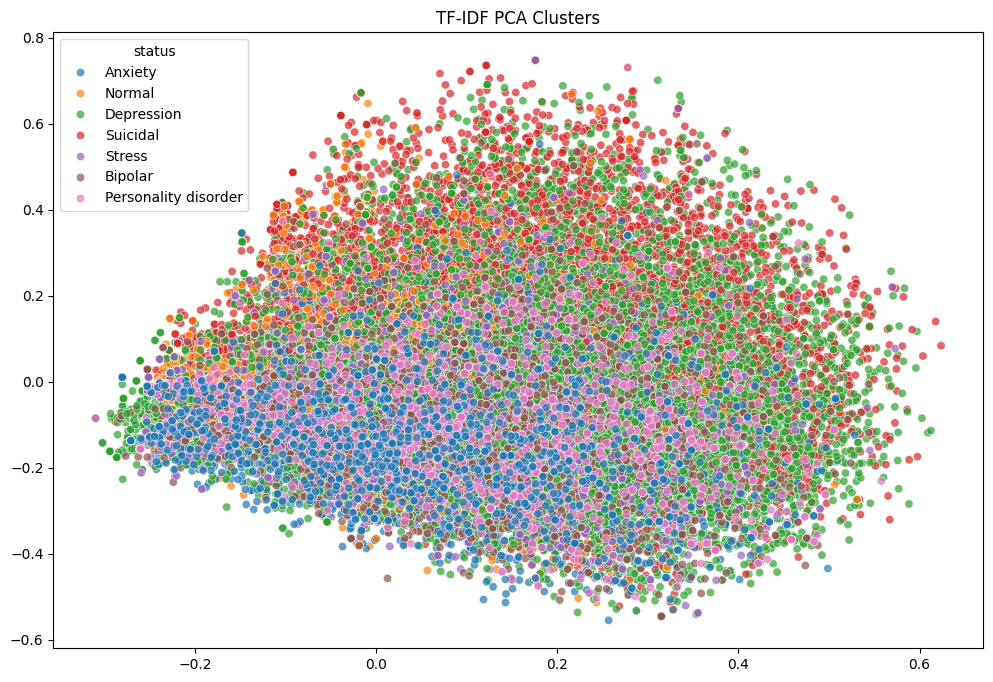

CPU times: total: 3.08 s
Wall time: 2.98 s


In [ ]:
%%time
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(12,8))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["status"],
    palette="tab10",
    alpha=0.7
)
plt.title("TF-IDF PCA Clusters")
plt.show()



## EMBEDDING CLUSTERS USING SENTENCE TRANSFORMERS

In [ ]:
%%time

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embed_model.encode(df["statement"].tolist(),
                                batch_size=64,
                                convert_to_numpy=True,
                                show_progress_bar=True)


Batches: 100%|██████████| 824/824 [16:45<00:00,  1.22s/it]


CPU times: total: 2h 5min 29s
Wall time: 16min 52s


## PCA ON EMBEDDINGS (VISUALIZE TRUE SEMANTIC CLUSTERS)

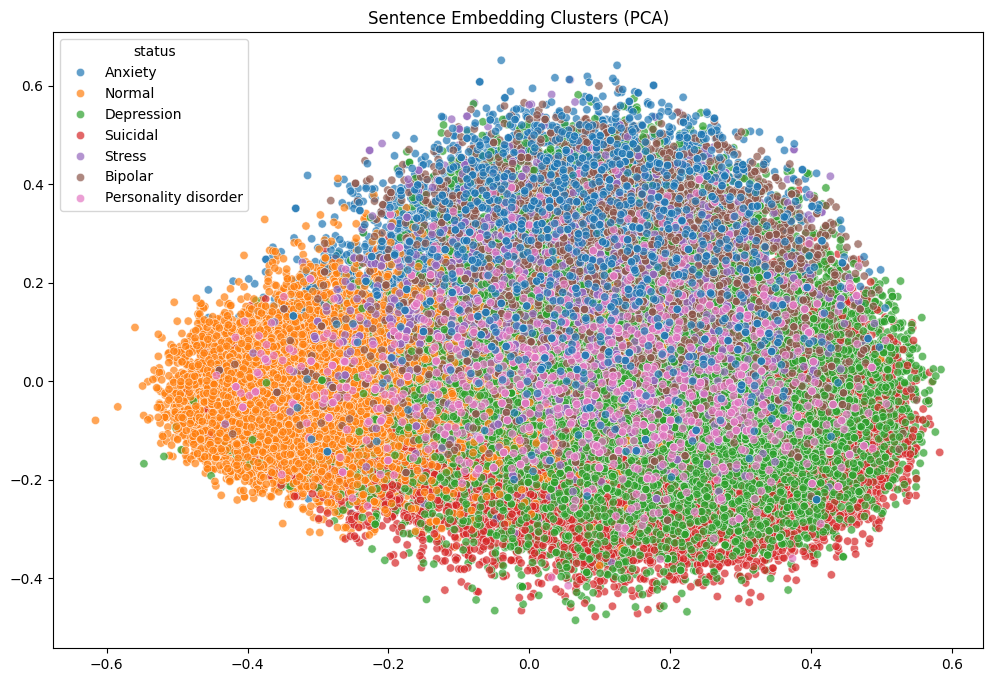

CPU times: total: 4.06 s
Wall time: 3.39 s


In [ ]:
%%time
pca_embed = PCA(n_components=2, random_state=42)
X_embed_pca = pca_embed.fit_transform(embeddings)

plt.figure(figsize=(12,8))
sns.scatterplot(
    x=X_embed_pca[:,0],
    y=X_embed_pca[:,1],
    hue=df["status"],
    palette="tab10",
    alpha=0.7
)
plt.title("Sentence Embedding Clusters (PCA)")
plt.show()


## UMAP CLUSTERS

d:\Mgit college\college projects\ML\code\mlProject\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


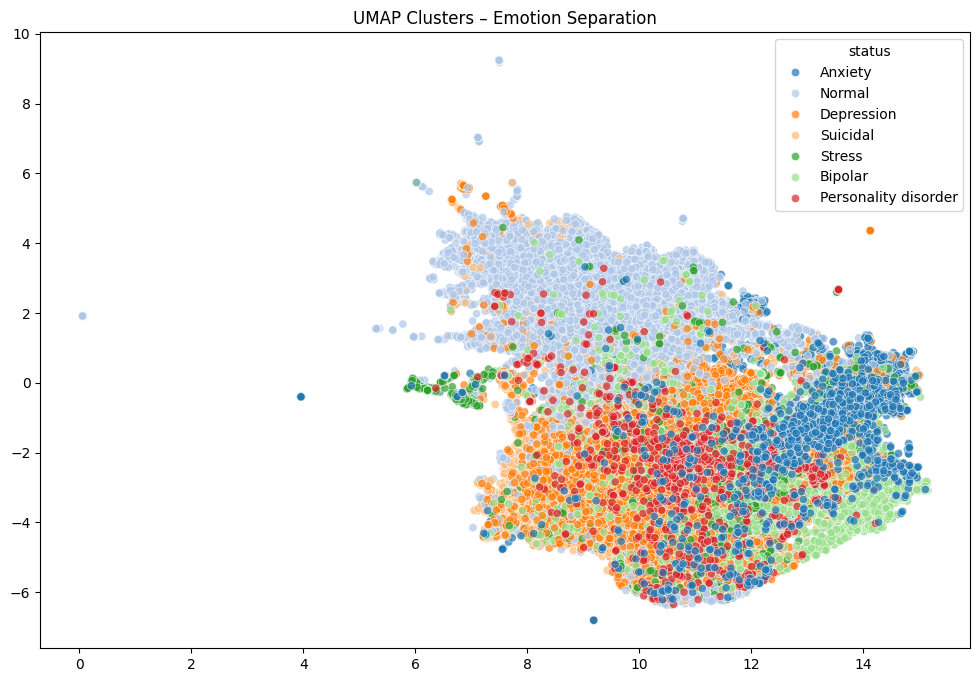

CPU times: total: 2min 15s
Wall time: 2min 3s


In [ ]:
%%time
um = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
X_umap = um.fit_transform(embeddings)

plt.figure(figsize=(12,8))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df["status"],
    palette="tab20",
    alpha=0.7
)
plt.title("UMAP Clusters – Emotion Separation")
plt.show()


#  Accuracy, F1-score and AUC Trend Across Folds

We plot fold-wise **Accuracy** and **Weighted F1-score** to observe model consistency across validation rounds.

> A smooth or flat trendline indicates strong generalization.  
> Sharp fluctuations may indicate data imbalance or model instability.

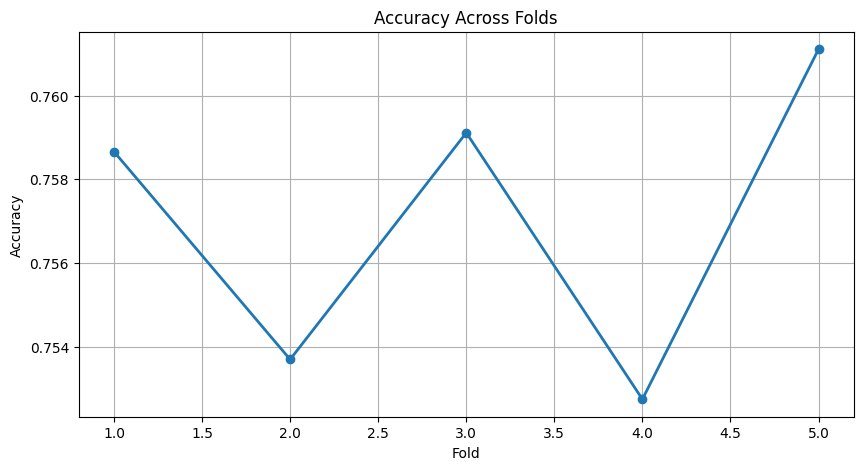

CPU times: total: 219 ms
Wall time: 229 ms


In [ ]:
%%time
folds = [d["fold"] for d in fold_reports_all]
accs  = [d["accuracy"] for d in fold_reports_all]

plt.figure(figsize=(10,5))
plt.plot(folds, accs, marker="o", linewidth=2)
plt.title("Accuracy Across Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


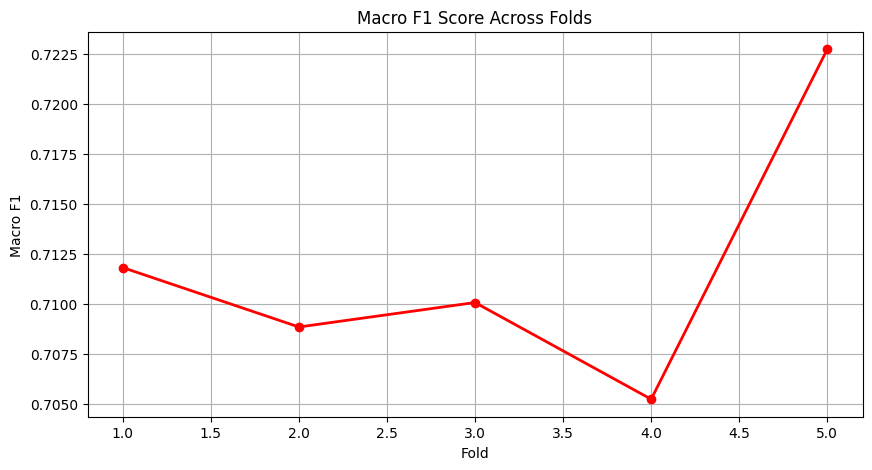

CPU times: total: 250 ms
Wall time: 249 ms


In [ ]:
%%time
f1s = [d["macro_f1"] for d in fold_reports_all]

plt.figure(figsize=(10,5))
plt.plot(folds, f1s, marker="o", linewidth=2, color="red")
plt.title("Macro F1 Score Across Folds")
plt.xlabel("Fold")
plt.ylabel("Macro F1")
plt.grid(True)
plt.show()


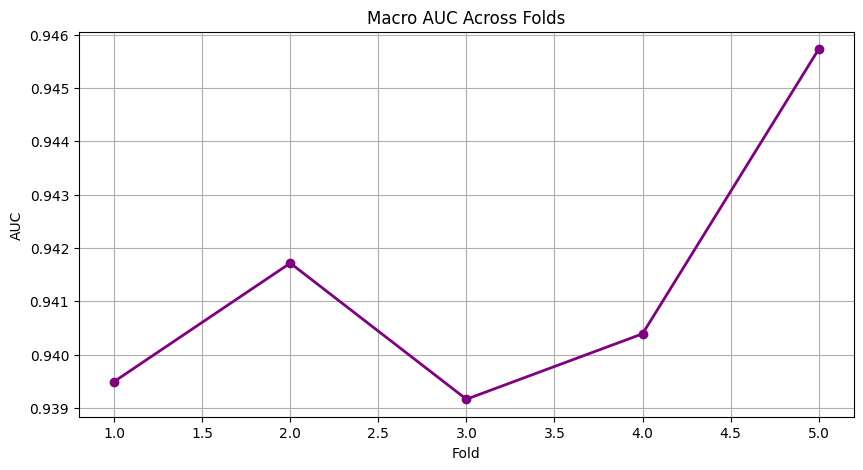

CPU times: total: 250 ms
Wall time: 239 ms


In [ ]:
%%time
aucs = [d["macro_auc"] for d in fold_reports_all]

plt.figure(figsize=(10,5))
plt.plot(folds, aucs, marker="o", linewidth=2, color="purple")
plt.title("Macro AUC Across Folds")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.grid(True)
plt.show()


In [ ]:
model = load("best_ensemble.pkl")

# Confusion Matrix Visualization

The **Confusion Matrix** provides a detailed view of how our model performs across all classes.

- The **diagonal cells** represent correct predictions.
- The **off-diagonal cells** show misclassifications between classes.

>  A strong model shows darker diagonals and lighter off-diagonals, indicating fewer confusions between labels.

This plot helps us identify which categories are often misclassified — for example, *Stress* and *Anxiety* tend to overlap in linguistic patterns.


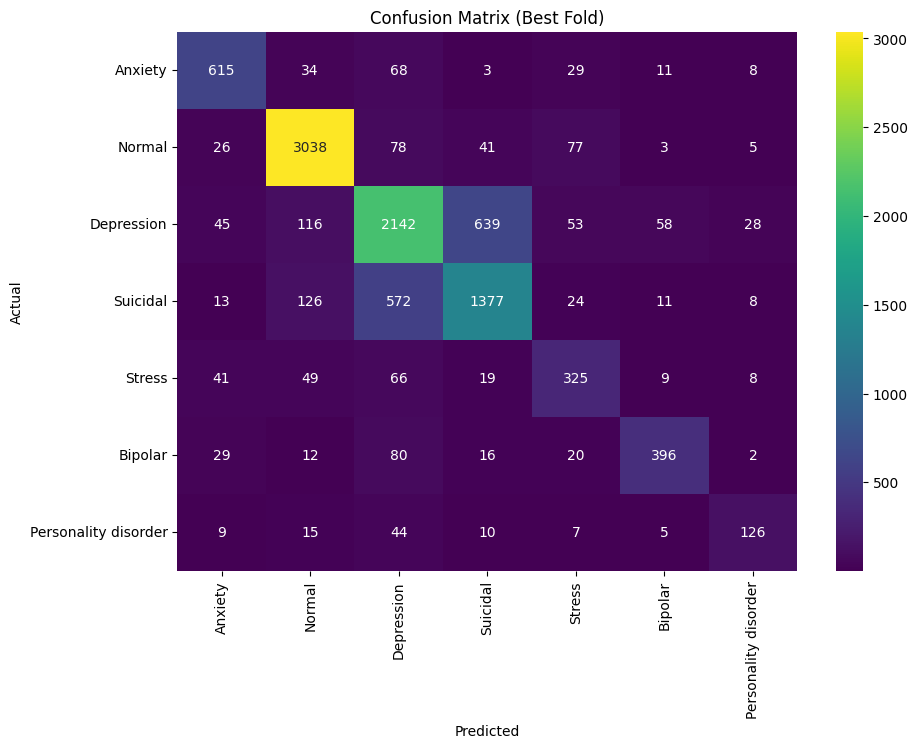

CPU times: total: 453 ms
Wall time: 478 ms


In [ ]:
%%time
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = best_fold_test["true"]
y_pred = best_fold_test["pred"]

cm = confusion_matrix(y_true, y_pred, labels=classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Best Fold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Radar Chart — Precision, Recall, and F1 per Class

This radar (spider) chart visualizes **Precision**, **Recall**, and **F1-score** for each class.

- Each triangle or shape represents a single class.
- The closer a shape is to the outer edge, the stronger its performance.

> This visualization makes it easy to spot imbalance between metrics across classes.


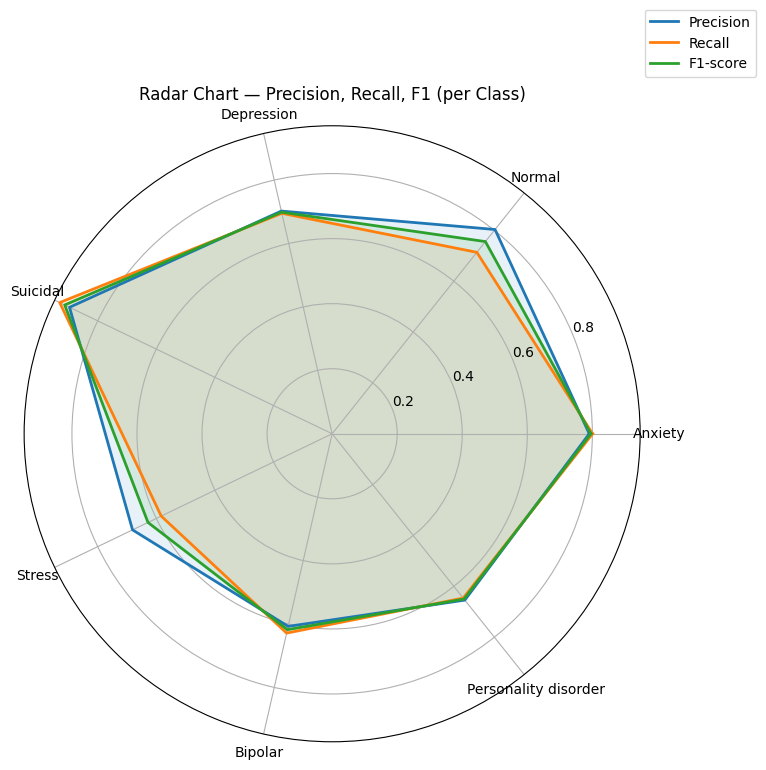

CPU times: total: 625 ms
Wall time: 628 ms


In [ ]:
%%time
from sklearn.metrics import classification_report
import numpy as np

# compute detailed metrics
report = classification_report(
    y_true, y_pred, target_names=classes, output_dict=True
)

labels = classes
precision = [report[c]["precision"] for c in classes]
recall    = [report[c]["recall"]    for c in classes]
f1        = [report[c]["f1-score"]  for c in classes]

# radar chart setup
angles = np.linspace(0, 2*np.pi, len(classes), endpoint=False).tolist()
precision += precision[:1]
recall    += recall[:1]
f1        += f1[:1]
angles   += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, precision, linewidth=2, label="Precision")
ax.fill(angles, precision, alpha=0.1)

ax.plot(angles, recall, linewidth=2, label="Recall")
ax.fill(angles, recall, alpha=0.1)

ax.plot(angles, f1, linewidth=2, label="F1-score")
ax.fill(angles, f1, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Radar Chart — Precision, Recall, F1 (per Class)")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.2))
plt.show()


# ROC Curves for Each Class (One-vs-Rest)

Here we visualize the **support (sample count)** for each class in the dataset.

> This chart highlights potential class imbalance and explains why certain labels may have lower performance — fewer samples mean less learning opportunity.


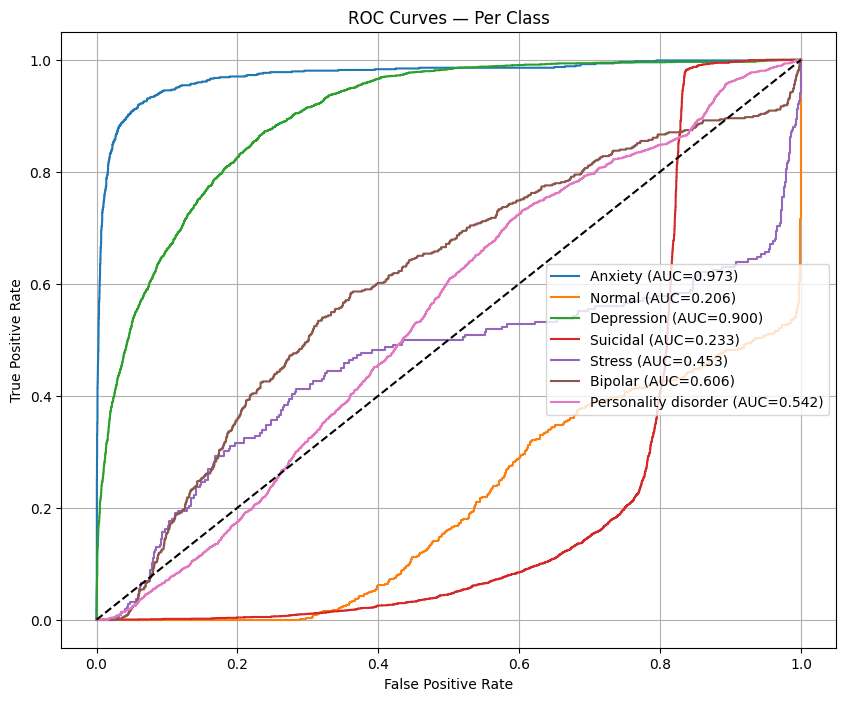

CPU times: total: 516 ms
Wall time: 475 ms


In [ ]:
%%time
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(best_fold_test["true"])
y_probas = best_fold_test[[f"proba_{c}" for c in classes]].values

plt.figure(figsize=(10,8))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probas[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{c} (AUC={auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Per Class")
plt.legend()
plt.grid(True)
plt.show()


# Precision vs Recall Scatter

This scatter plot visualizes the trade-off between precision and recall for each fold.

- Points closer to the top-right corner indicate well-balanced models.
- A cluster of folds shows consistency.

> It’s a quick way to see if our ensemble maintains equilibrium between false positives and false negatives.


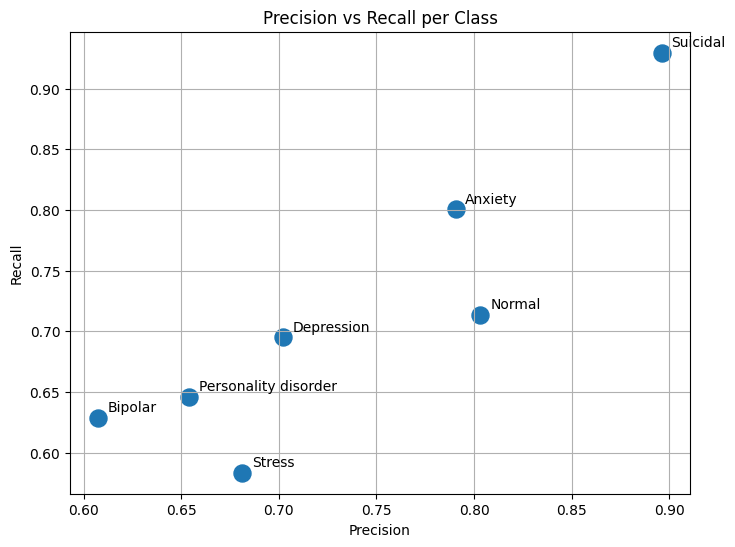

CPU times: total: 266 ms
Wall time: 259 ms


In [ ]:
%%time
precision_vals = [report[c]["precision"] for c in classes]
recall_vals    = [report[c]["recall"] for c in classes]

plt.figure(figsize=(8,6))
plt.scatter(precision_vals, recall_vals, s=150)

for i, c in enumerate(classes):
    plt.text(precision_vals[i]+0.005, recall_vals[i]+0.005, c)

plt.title("Precision vs Recall per Class")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.grid(True)
plt.show()


# Precision-Recall Curves (Per Class)

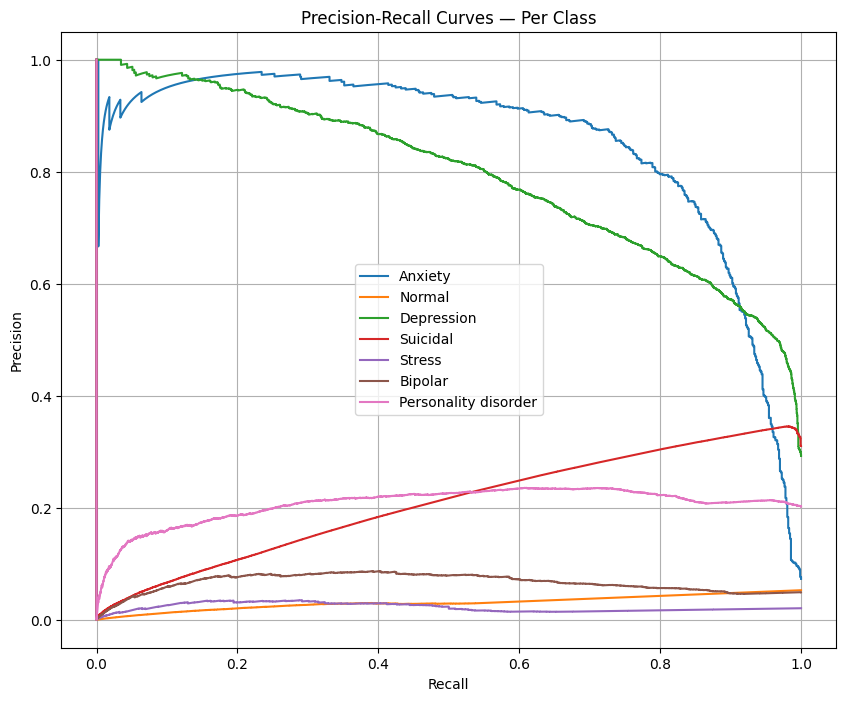

CPU times: total: 766 ms
Wall time: 768 ms


In [ ]:
%%time
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10,8))

for i, c in enumerate(classes):
    pr, rc, _ = precision_recall_curve(y_test_bin[:, i], y_probas[:, i])
    plt.plot(rc, pr, label=f"{c}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Per Class")
plt.legend()
plt.grid(True)
plt.show()


# Model Performance Summary Heatmap

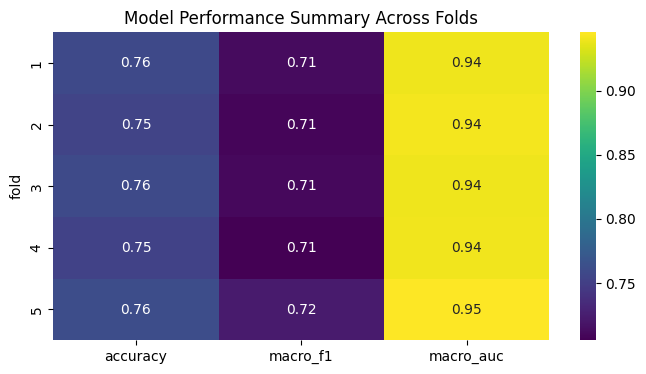

CPU times: total: 266 ms
Wall time: 262 ms


In [ ]:
%%time
summary_df = pd.DataFrame({
    "fold": folds,
    "accuracy": accs,
    "macro_f1": f1s,
    "macro_auc": aucs,
})

plt.figure(figsize=(8,4))
sns.heatmap(summary_df.set_index("fold"), annot=True, cmap="viridis")
plt.title("Model Performance Summary Across Folds")
plt.show()


# Testing diff code diff models


In [ ]:
# # !pip install -q transformers accelerate einops bitsandbytes
# !pip install sentence-transformers
# !pip install imbalanced-learn
# run in a cell with `!` prefix
# !pip install -q sentence-transformers xgboost joblib
# If you only want TF-IDF pipeline, sentence-transformers is optional
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.10.1


In [ ]:
# === Ensemble pipeline (no CatBoost) - supports transformer-embeddings OR TF-IDF ===
import os, json, time
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import dump
from sentence_transformers import SentenceTransformer

# ---------- USER OPTIONS ----------
CSV_PATH = "/kaggle/input/minddataset/Combined Data.csv"
TEXT_COL = "statement"
LABEL_COL = "status"

USE_TRANSFORMER = True   # True -> use SentenceTransformer embeddings (recommended if GPU available)
N_SPLITS = 5
RANDOM_STATE = 42
SAVE_DIR = "model_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)
# ----------------------------------

# Load data
df = pd.read_csv(CSV_PATH)
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
texts = df[TEXT_COL].astype(str).tolist()
labels = df[LABEL_COL].astype(str).tolist()
classes = sorted(df[LABEL_COL].unique().tolist())
y = np.array(labels)
print("Loaded:", df.shape, "Classes:", classes)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device for embeddings:", device)

# --------- Prepare features ----------
if USE_TRANSFORMER:
    print("Loading SentenceTransformer and computing embeddings (this uses GPU if available)...")
    embed_model = "all-MiniLM-L6-v2"
    embedder = SentenceTransformer(embed_model, device=device)
    X = embedder.encode(texts, batch_size=64, convert_to_numpy=True, show_progress_bar=True)
    # We will use only models that accept dense inputs: XGB, RF, LR, SVC
    use_nb = False
    print("Embeddings shape:", X.shape)
else:
    print("Using TF-IDF features + MultinomialNB")
    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        analyzer="word",
        max_df=0.95,
        min_df=3
    )
    X = vectorizer.fit_transform(texts)
    use_nb = True
    print("TF-IDF shape:", X.shape)

# --------- Define base models (only the algorithms you know) ----------
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="gpu_hist" if device=="cuda" else "hist",
    predictor="gpu_predictor" if device=="cuda" else "auto",
    random_state=RANDOM_STATE,
    verbosity=0
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    multi_class='multinomial',
    solver='lbfgs'
)

svc = SVC(
    probability=True,
    kernel="rbf",
    C=2.0,
    gamma="scale",
    random_state=RANDOM_STATE
)

nb = MultinomialNB()  # only used if TF-IDF pipeline

# --------- Construct ensemble depending on feature type ----------
if USE_TRANSFORMER:
    estimators = [("xgb", xgb), ("rf", rf), ("lr", lr), ("svc", svc)]
    weights = [3, 3, 1, 1]   # heavier weights to tree models
else:
    # MultinomialNB is strong on TF-IDF; include it
    estimators = [("nb", nb), ("xgb", xgb), ("rf", rf), ("lr", lr)]
    weights = [2, 3, 3, 1]

ensemble = VotingClassifier(estimators=estimators, voting="soft", weights=weights, n_jobs=1)

# --------- Cross-validation and evaluation (macro AUC OVR) ----------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

best_auc = -1.0
best_model = None
fold_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n=== Fold {fold} ===")
    start = time.time()

    if USE_TRANSFORMER:
        X_train, X_test = X[train_idx], X[test_idx]
    else:
        X_train, X_test = X[train_idx], X[test_idx]  # sparse slicing works

    y_train, y_test = y[train_idx], y[test_idx]

    # Fit ensemble
    ensemble.fit(X_train, y_train)

    # Predict
    y_pred = ensemble.predict(X_test)
    y_proba = ensemble.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    lb = LabelBinarizer().fit(classes)
    y_test_bin = lb.transform(y_test)
    try:
        auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro")
    except Exception as e:
        print("roc_auc_score error:", e)
        auc = float("nan")

    print(f"Fold {fold} -> acc: {acc:.4f} | macro_f1: {macro_f1:.4f} | macro_auc_ovr: {auc:.4f}")

    fold_results.append({"fold":fold, "acc":float(acc), "macro_f1":float(macro_f1), "auc":float(auc)})

    # Save best by AUC
    if not np.isnan(auc) and auc > best_auc:
        best_auc = auc
        best_model = ensemble
        # Persist
        dump(best_model, os.path.join(SAVE_DIR, "best_voting_ensemble.joblib"))
        if USE_TRANSFORMER:
            dump(embedder, os.path.join(SAVE_DIR, "sentence_transformer.joblib"))
        else:
            dump(vectorizer, os.path.join(SAVE_DIR, "tfidf_vectorizer.joblib"))
        print(f"🔥 New best model saved (Fold {fold}) | AUC={best_auc:.4f}")

print("\n=== Summary ===")
res_df = pd.DataFrame(fold_results)
print(res_df)
print("Mean acc:", res_df["acc"].mean())
print("Mean macro_f1:", res_df["macro_f1"].mean())
print("Mean macro_auc_ovr:", res_df["auc"].mean())

# Save results
with open(os.path.join(SAVE_DIR, "fold_results.json"), "w") as f:
    json.dump(fold_results, f, indent=4)

print("Artifacts saved in:", SAVE_DIR)


In [ ]:
"hello world"

In [ ]:
94939